# Comprehensive Emotion Analysis Across BERTopic Topics

Analysis of 28 GoEmotions across 19 BERTopic topics from mental health Reddit posts.

**Analyses:**
1. Full 28-Emotion Heatmap
2. Emotion Categories Comparison
3. Emotion Radar Charts
4. Distinctive Emotions (Z-scores)
5. Emotion Co-occurrence Correlation
6. Hierarchical Clustering Dendrogram
7. Dominant Emotion Distribution
8. Summary Statistics Export

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ALL_EMOTIONS = [
    'admiration', 'amusement', 'approval', 'caring', 'desire', 'excitement',
    'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief',
    'anger', 'annoyance', 'disappointment', 'disapproval', 'disgust',
    'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness',
    'confusion', 'curiosity', 'realization', 'surprise', 'neutral'
]

POSITIVE_EMOTIONS = ['admiration', 'amusement', 'approval', 'caring', 'desire',
                     'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief']

NEGATIVE_EMOTIONS = ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust',
                     'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness']

AMBIGUOUS_EMOTIONS = ['confusion', 'curiosity', 'realization', 'surprise']

NEUTRAL_EMOTIONS = ['neutral']

In [4]:
DATA_PATH = '/content/drive/MyDrive/mental_health_research_V2/results/bertopic_analysis/reddit_with_topics_20251121_230630.json'
TOPIC_INFO_PATH = '/content/drive/MyDrive/mental_health_research_V2/results/bertopic_analysis/topic_info_20251121_230630.csv'
OUTPUT_DIR = '/content/drive/MyDrive/mental_health_research_V2/results/comprehensive_emotion_analysis/visualizations/'

assert os.path.exists(DATA_PATH), f'Data file not found: {DATA_PATH}'
assert os.path.exists(TOPIC_INFO_PATH), f'Topic info file not found: {TOPIC_INFO_PATH}'

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_json(DATA_PATH)
topic_info = pd.read_csv(TOPIC_INFO_PATH)
topic_names = dict(zip(topic_info['Topic'], topic_info['Llama']))

print(f'Posts: {len(df):,}')
print(f'Topics: {len(topic_names)}')

Posts: 36,177
Topics: 20


In [5]:
if 'emotion_probabilities' in df.columns:
    emotion_data = pd.json_normalize(df['emotion_probabilities'])
    missing_emotions = set(ALL_EMOTIONS) - set(emotion_data.columns)
    if missing_emotions:
        raise ValueError(f'Missing emotions in data: {missing_emotions}')
    for emotion in ALL_EMOTIONS:
        if emotion not in df.columns:
            df[emotion] = emotion_data[emotion]
else:
    missing_emotions = set(ALL_EMOTIONS) - set(df.columns)
    if missing_emotions:
        raise ValueError(f'Emotion columns not found. Missing: {missing_emotions}')

df_topics = df[df['topic'] != -1].copy()
print(f'Valid topics: {len(df_topics):,}')

if len(df_topics) == 0:
    raise ValueError('No valid topics found (all posts are outliers with topic=-1)')

actual_topics = set(df_topics['topic'].unique())
loaded_topics = set(topic_names.keys())
missing_topic_names = actual_topics - loaded_topics
if missing_topic_names:
    print(f'WARNING: Topic names missing for IDs: {sorted(missing_topic_names)}')

Valid topics: 31,539


## 1. Full 28-Emotion Heatmap

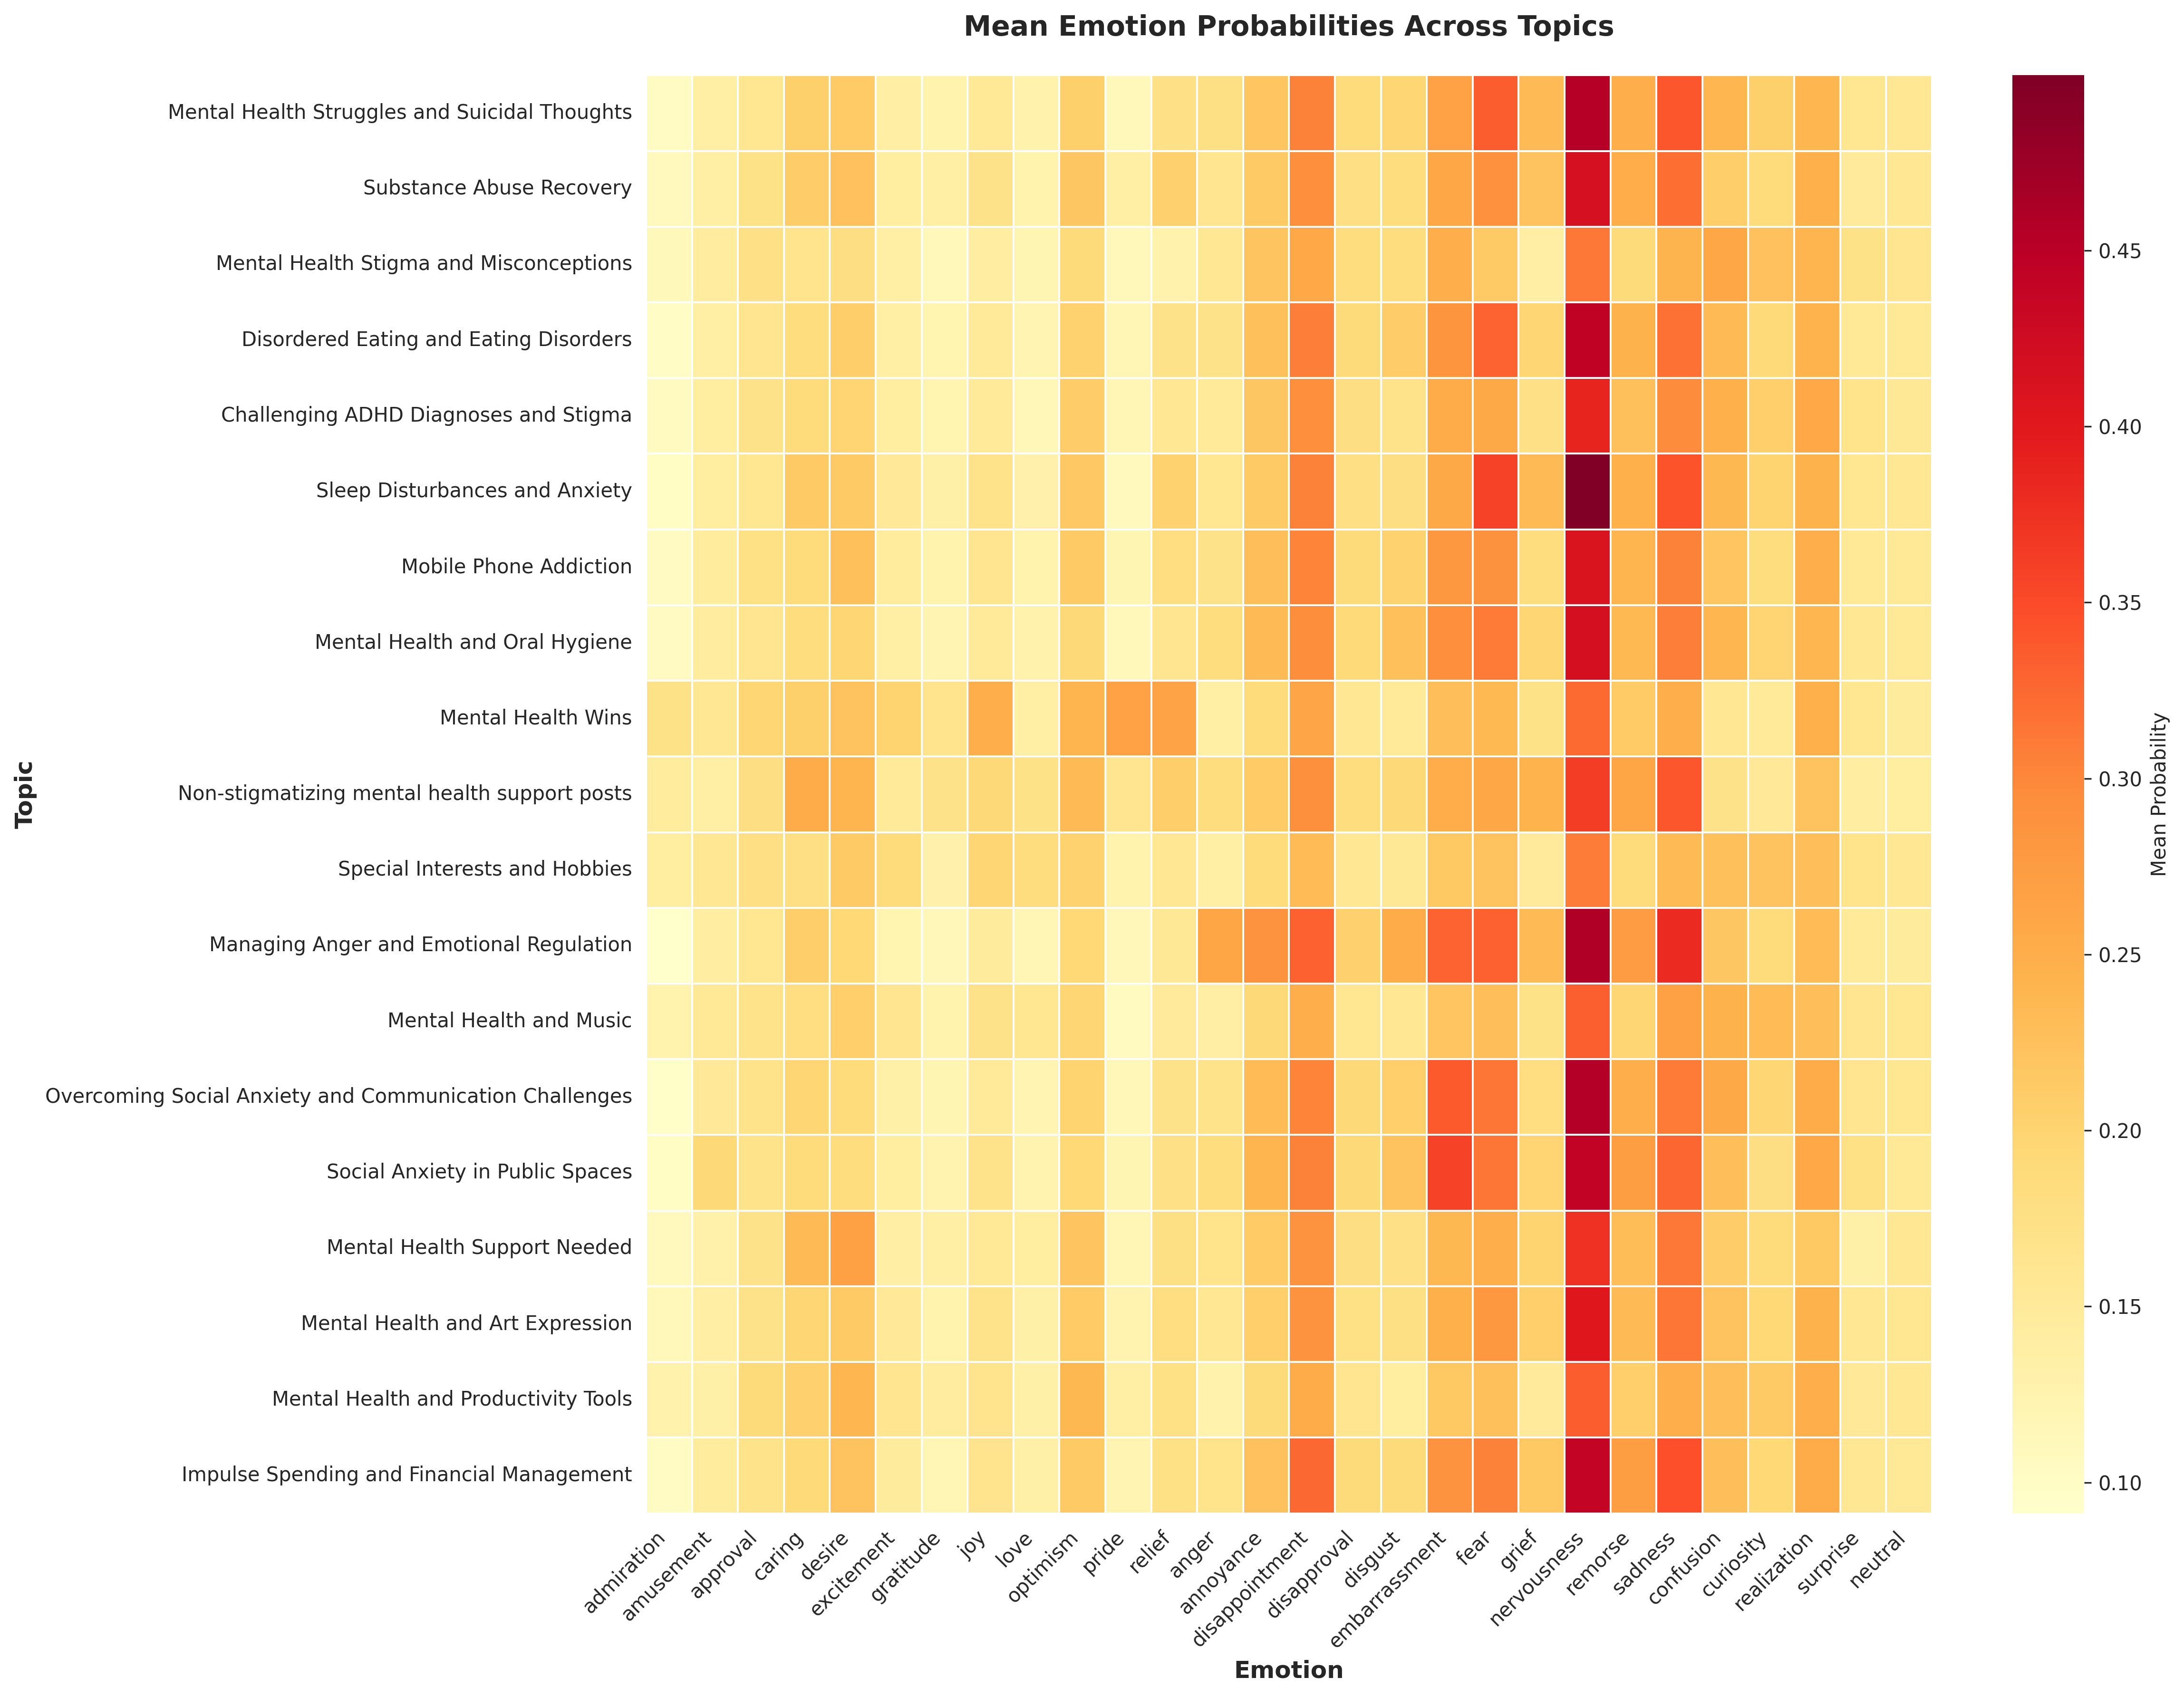

In [6]:
emotion_by_topic = df_topics.groupby('topic')[ALL_EMOTIONS].mean()
reverse_topic_names = {v: k for k, v in topic_names.items()}
emotion_by_topic.index = emotion_by_topic.index.map(lambda x: topic_names.get(x, f'Topic {x}'))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(emotion_by_topic, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Mean Probability'},
            linewidths=0.5, ax=ax)
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_ylabel('Topic', fontsize=12, fontweight='bold')
ax.set_title('Mean Emotion Probabilities Across Topics', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'full_28_emotions_heatmap.png'), bbox_inches='tight')
plt.show()

## 2. Emotion Categories Comparison

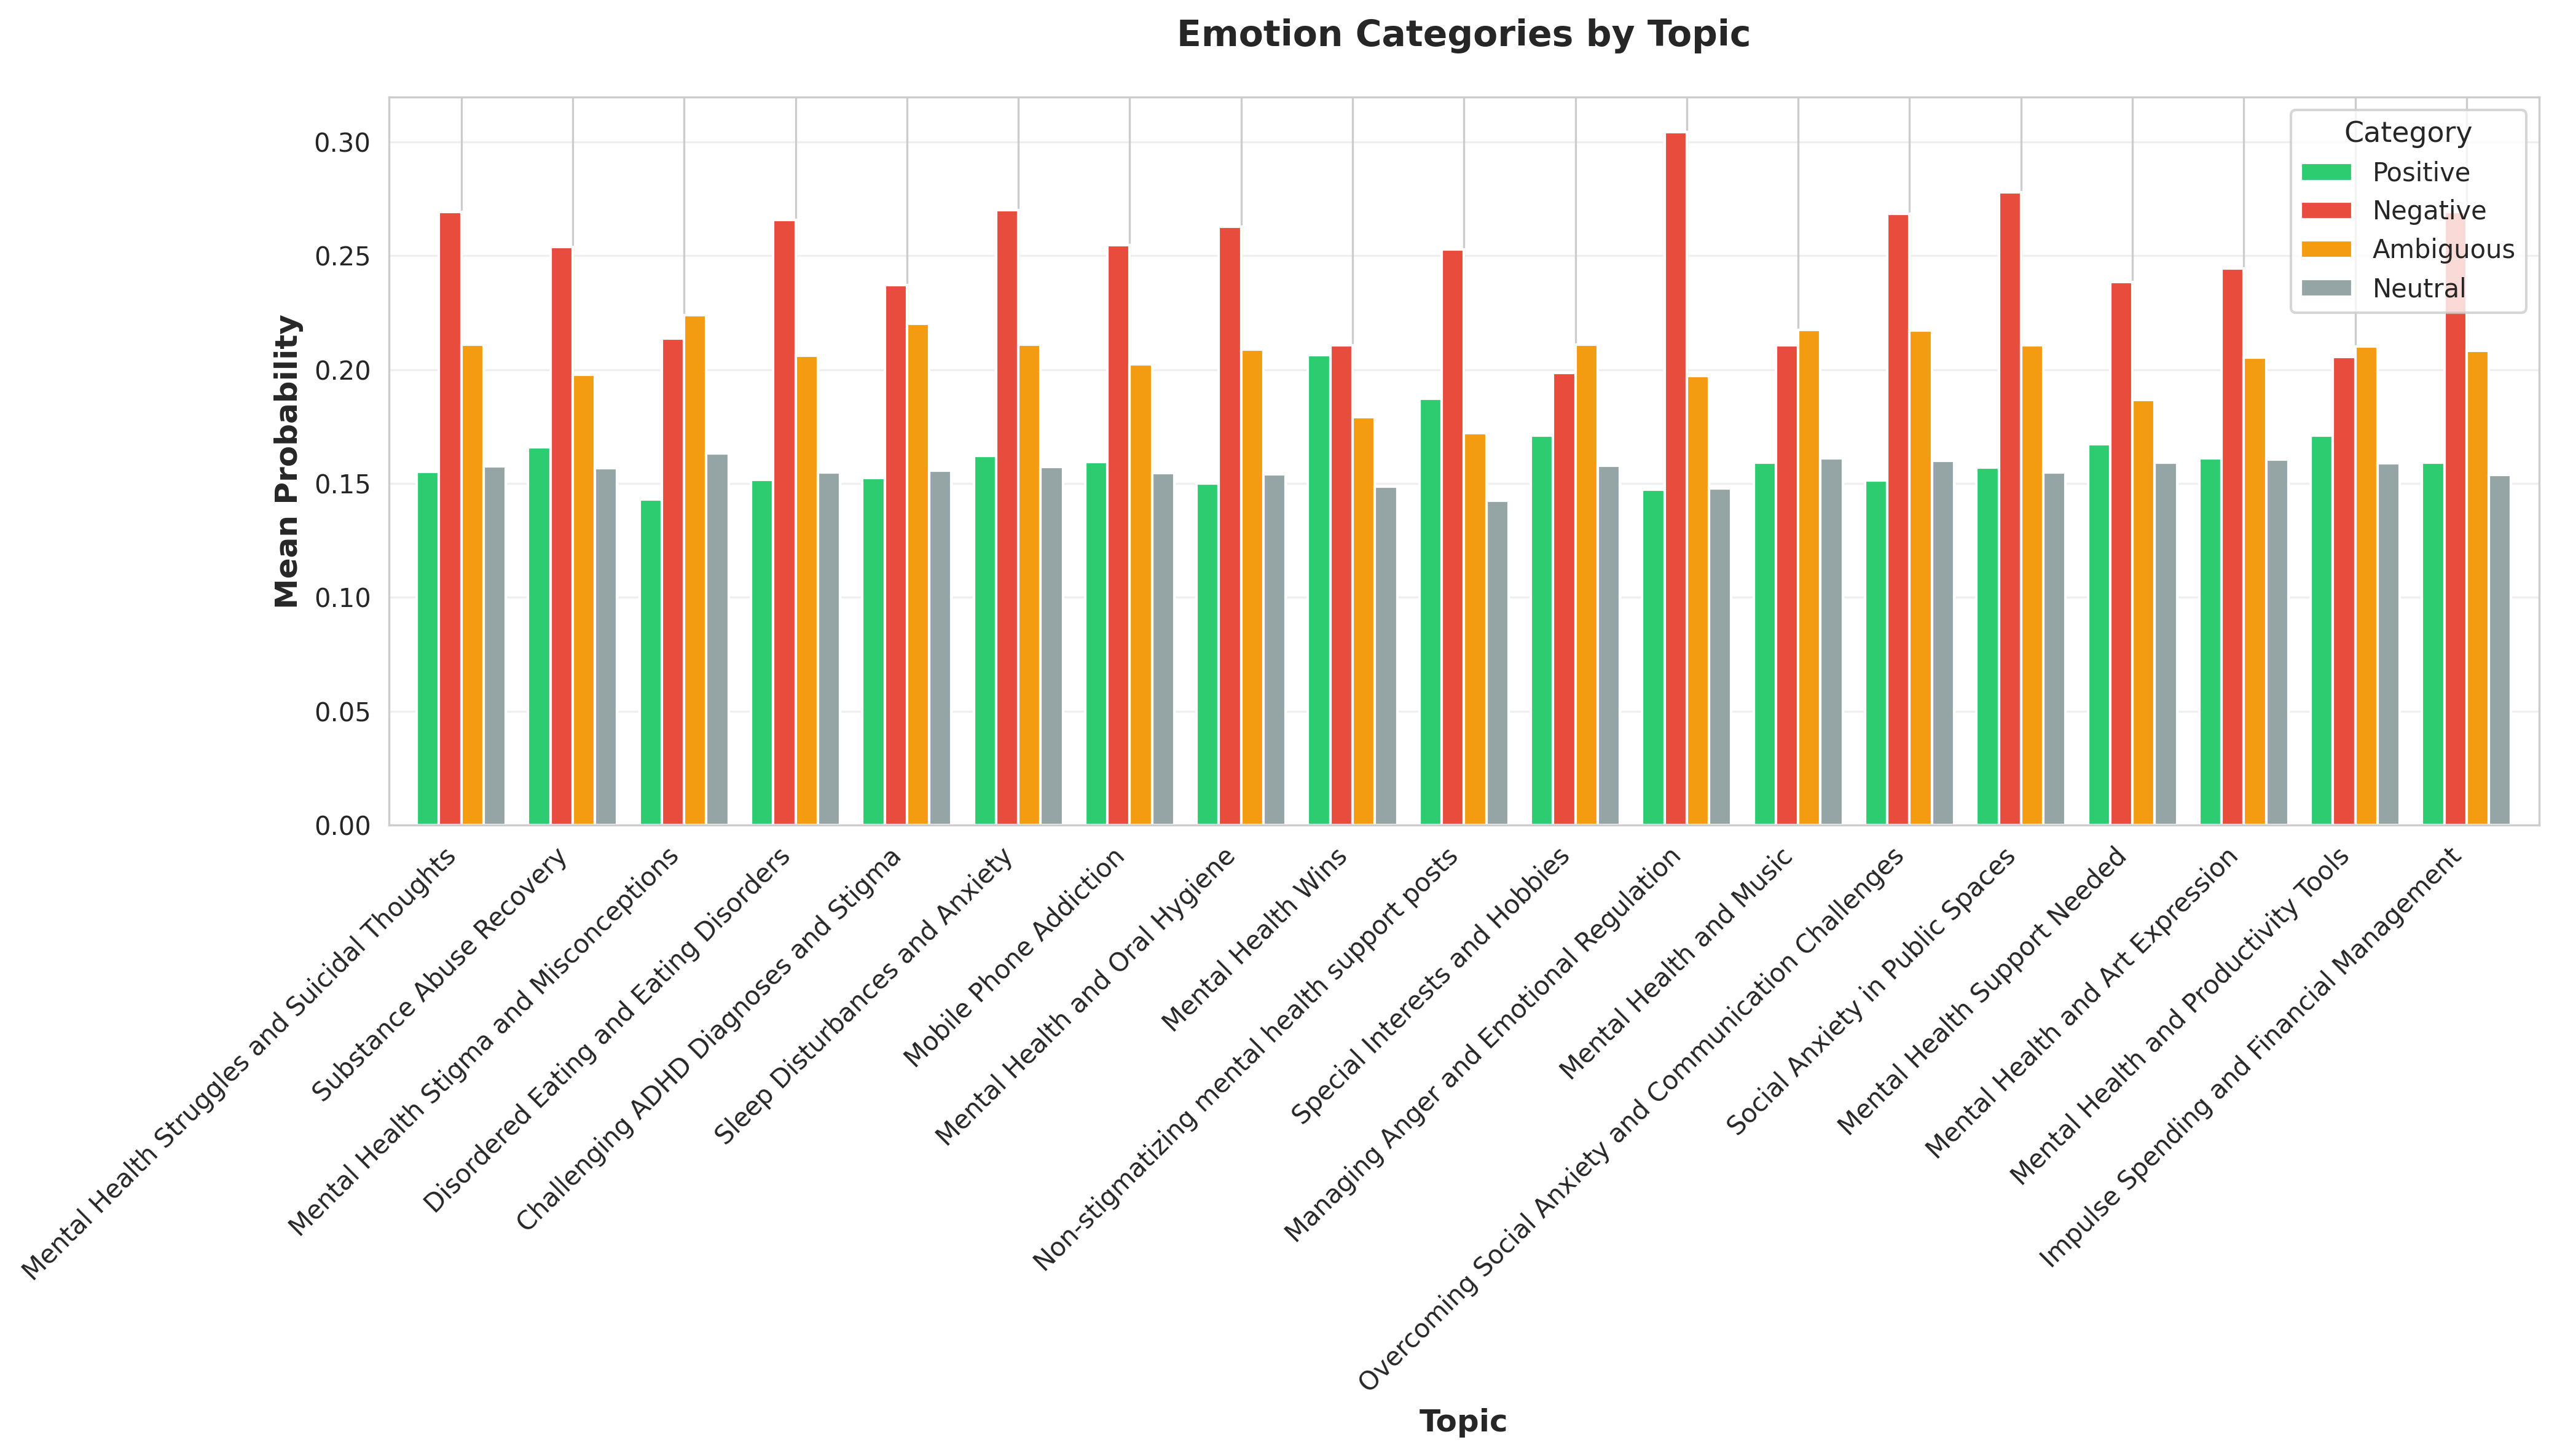

In [7]:
category_by_topic = pd.DataFrame({
    'Positive': df_topics.groupby('topic')[POSITIVE_EMOTIONS].mean().mean(axis=1),
    'Negative': df_topics.groupby('topic')[NEGATIVE_EMOTIONS].mean().mean(axis=1),
    'Ambiguous': df_topics.groupby('topic')[AMBIGUOUS_EMOTIONS].mean().mean(axis=1),
    'Neutral': df_topics.groupby('topic')[NEUTRAL_EMOTIONS].mean().mean(axis=1)
})

category_by_topic.index = category_by_topic.index.map(lambda x: topic_names.get(x, f'Topic {x}'))

fig, ax = plt.subplots(figsize=(14, 8))
category_by_topic.plot(kind='bar', ax=ax, width=0.8,
                       color=['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6'])
ax.set_xlabel('Topic', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Probability', fontsize=12, fontweight='bold')
ax.set_title('Emotion Categories by Topic', fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Category', fontsize=10, title_fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'emotion_categories_by_topic.png'), bbox_inches='tight')
plt.show()

## 3. Emotion Radar Charts

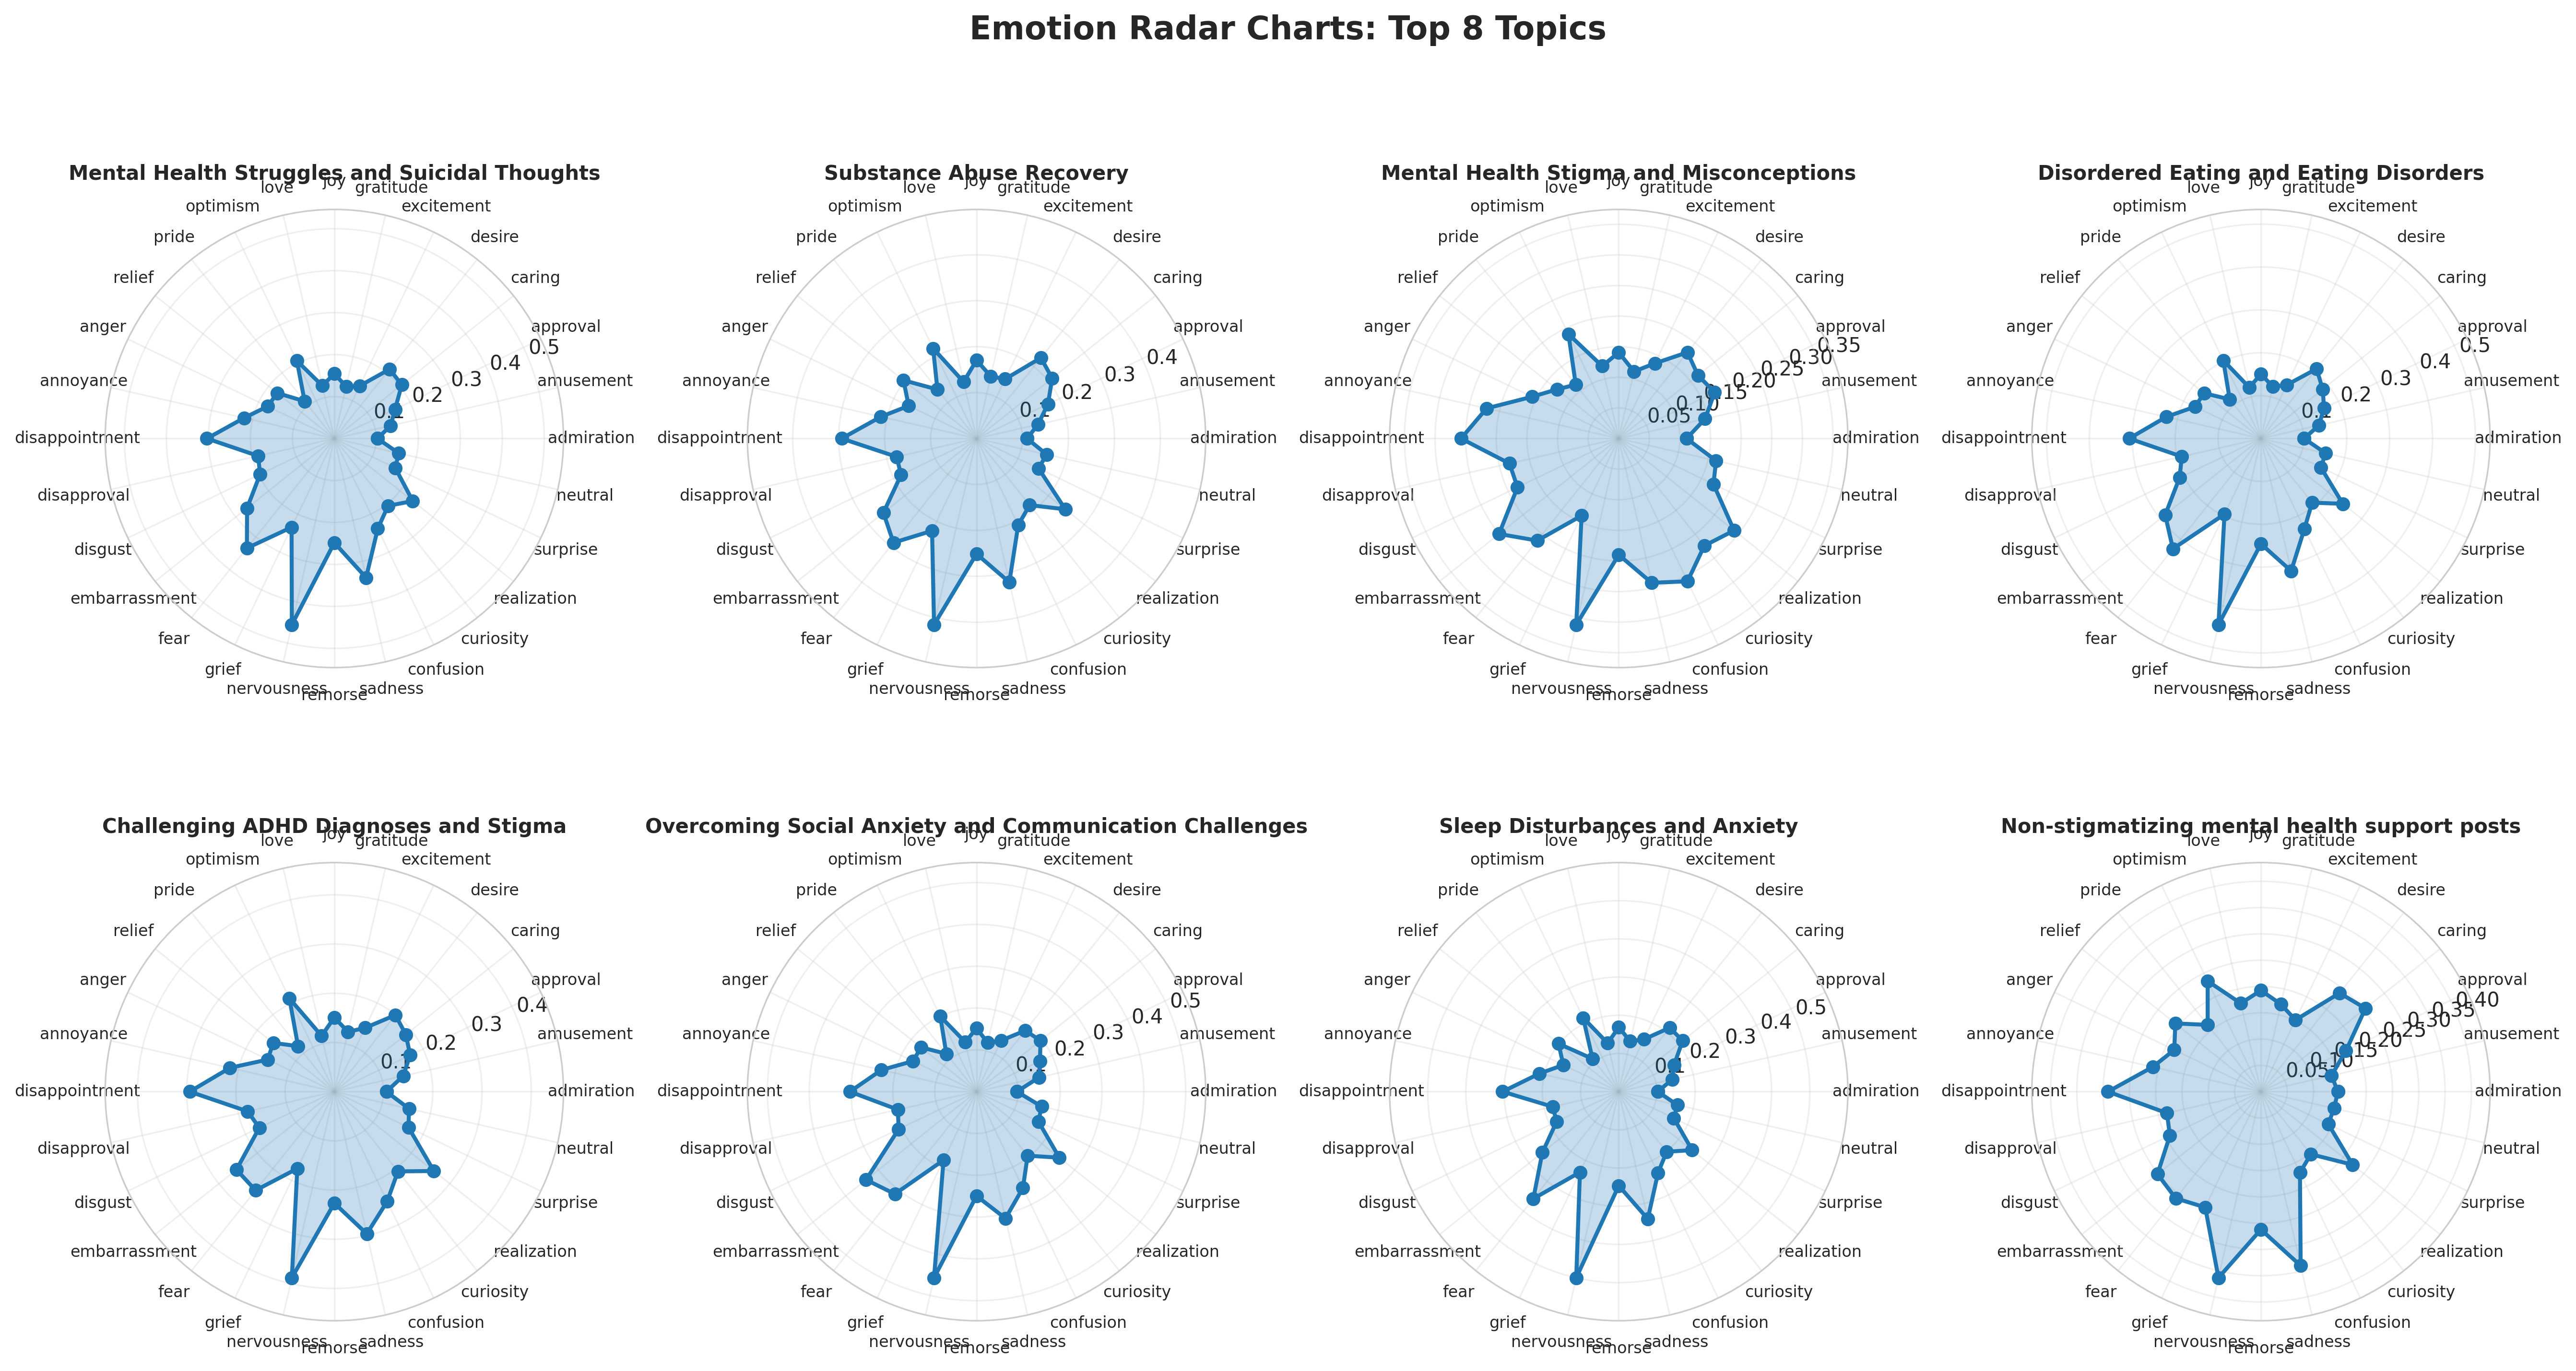

In [8]:
top_topics = df_topics['topic'].value_counts().head(8).index.tolist()

def create_radar_chart(ax, topic_id, topic_name, values, emotions):
    angles = np.linspace(0, 2 * np.pi, len(emotions), endpoint=False).tolist()
    values = values.tolist()
    values += values[:1]
    angles += angles[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=topic_name)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(emotions, size=8)
    ax.set_ylim(0, max(0.01, max(values) * 1.2))
    ax.set_title(topic_name, size=10, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)

fig = plt.figure(figsize=(18, 10))
for idx, topic_id in enumerate(top_topics):
    ax = fig.add_subplot(2, 4, idx + 1, projection='polar')
    topic_name = topic_names.get(topic_id, f'Topic {topic_id}')
    topic_emotions = df_topics[df_topics['topic'] == topic_id][ALL_EMOTIONS].mean()
    create_radar_chart(ax, topic_id, topic_name, topic_emotions.values, ALL_EMOTIONS)

fig.suptitle('Emotion Radar Charts: Top 8 Topics', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, 'emotion_radar_charts.png'), bbox_inches='tight')
plt.show()

## 4. Distinctive Emotions (Z-scores)

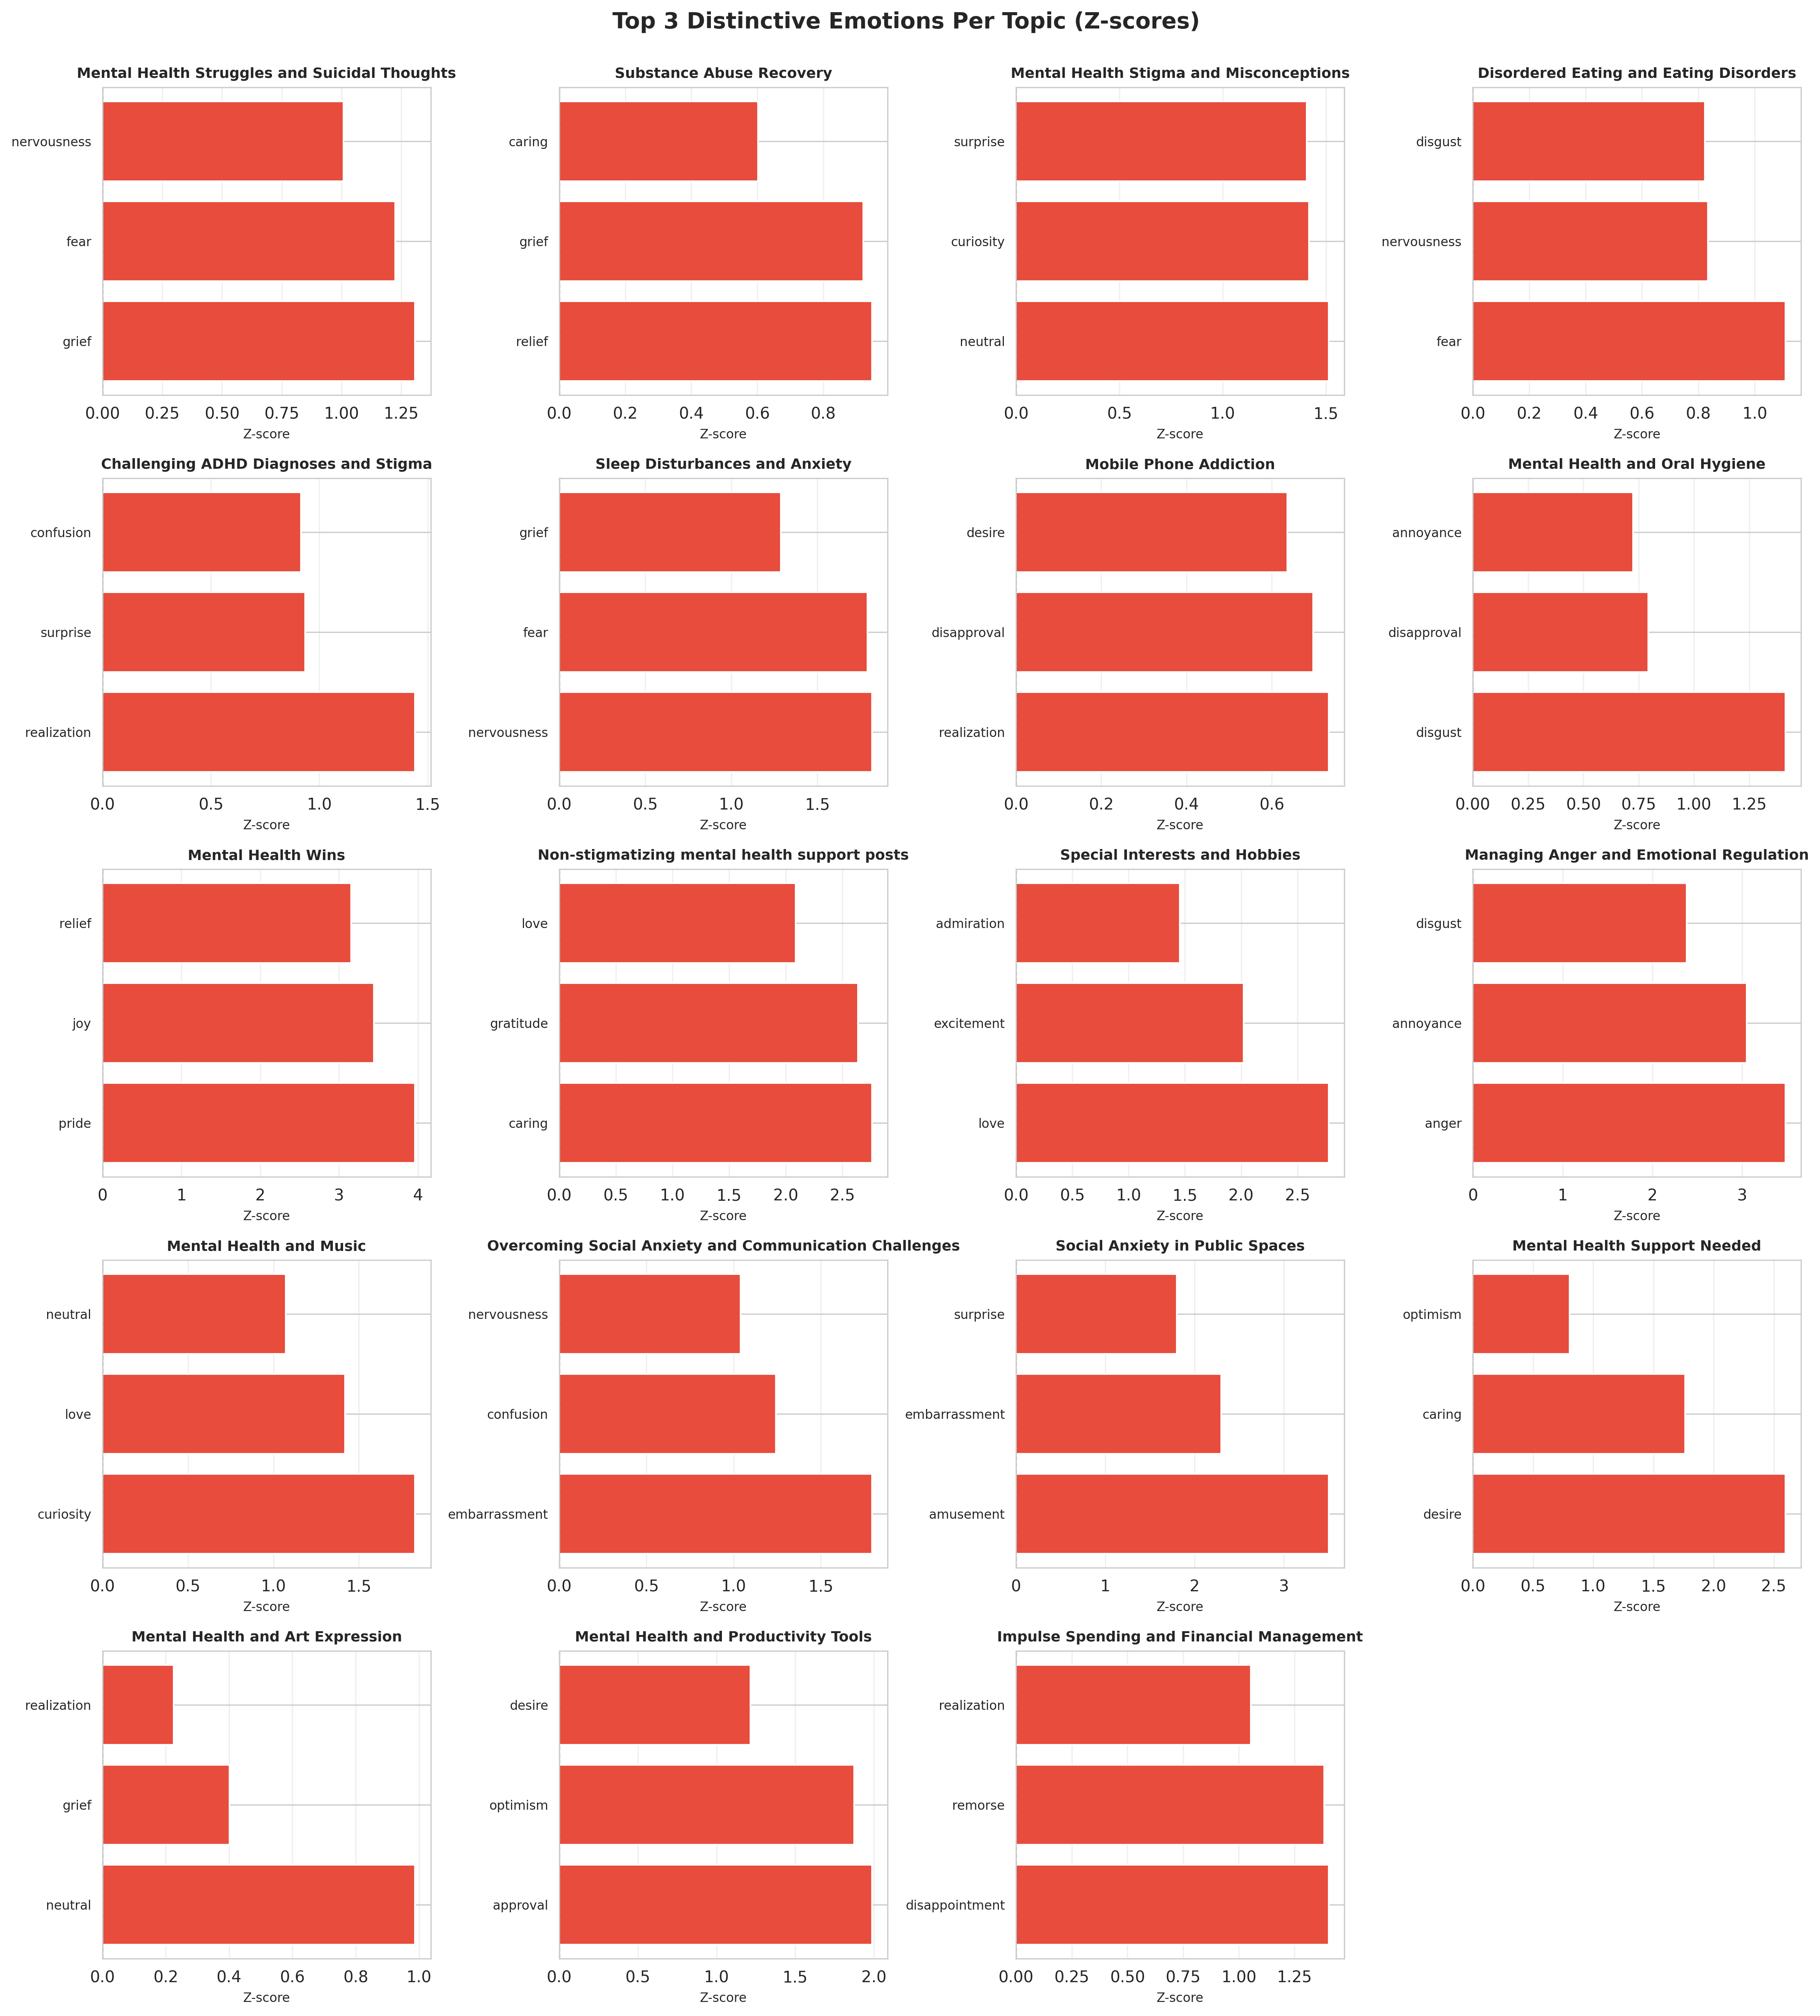

In [9]:
scaler = StandardScaler()
emotion_z_scores = pd.DataFrame(
    scaler.fit_transform(emotion_by_topic),
    index=emotion_by_topic.index,
    columns=emotion_by_topic.columns
)

top_distinctive = {}
for topic in emotion_z_scores.index:
    top_3 = emotion_z_scores.loc[topic].nlargest(3)
    top_distinctive[topic] = top_3

n_topics = len(top_distinctive)
if n_topics > 20:
    print(f'WARNING: Showing only first 20 of {n_topics} topics in distinctive emotions chart')
    top_distinctive = dict(list(top_distinctive.items())[:20])
    n_topics = 20

fig, axes = plt.subplots(5, 4, figsize=(16, 18))
axes = axes.flatten()

for idx, (topic, emotions) in enumerate(top_distinctive.items()):
    if idx < len(axes):
        ax = axes[idx]
        colors = ['#e74c3c' if v > 0 else '#3498db' for v in emotions.values]
        ax.barh(range(len(emotions)), emotions.values, color=colors)
        ax.set_yticks(range(len(emotions)))
        ax.set_yticklabels(emotions.index, fontsize=8)
        ax.set_xlabel('Z-score', fontsize=8)
        ax.set_title(topic, fontsize=9, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
        ax.grid(axis='x', alpha=0.3)

for idx in range(len(top_distinctive), len(axes)):
    fig.delaxes(axes[idx])

fig.suptitle('Top 3 Distinctive Emotions Per Topic (Z-scores)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(OUTPUT_DIR, 'distinctive_emotions_by_topic.png'), bbox_inches='tight')
plt.show()

## 5. Emotion Co-occurrence Correlation

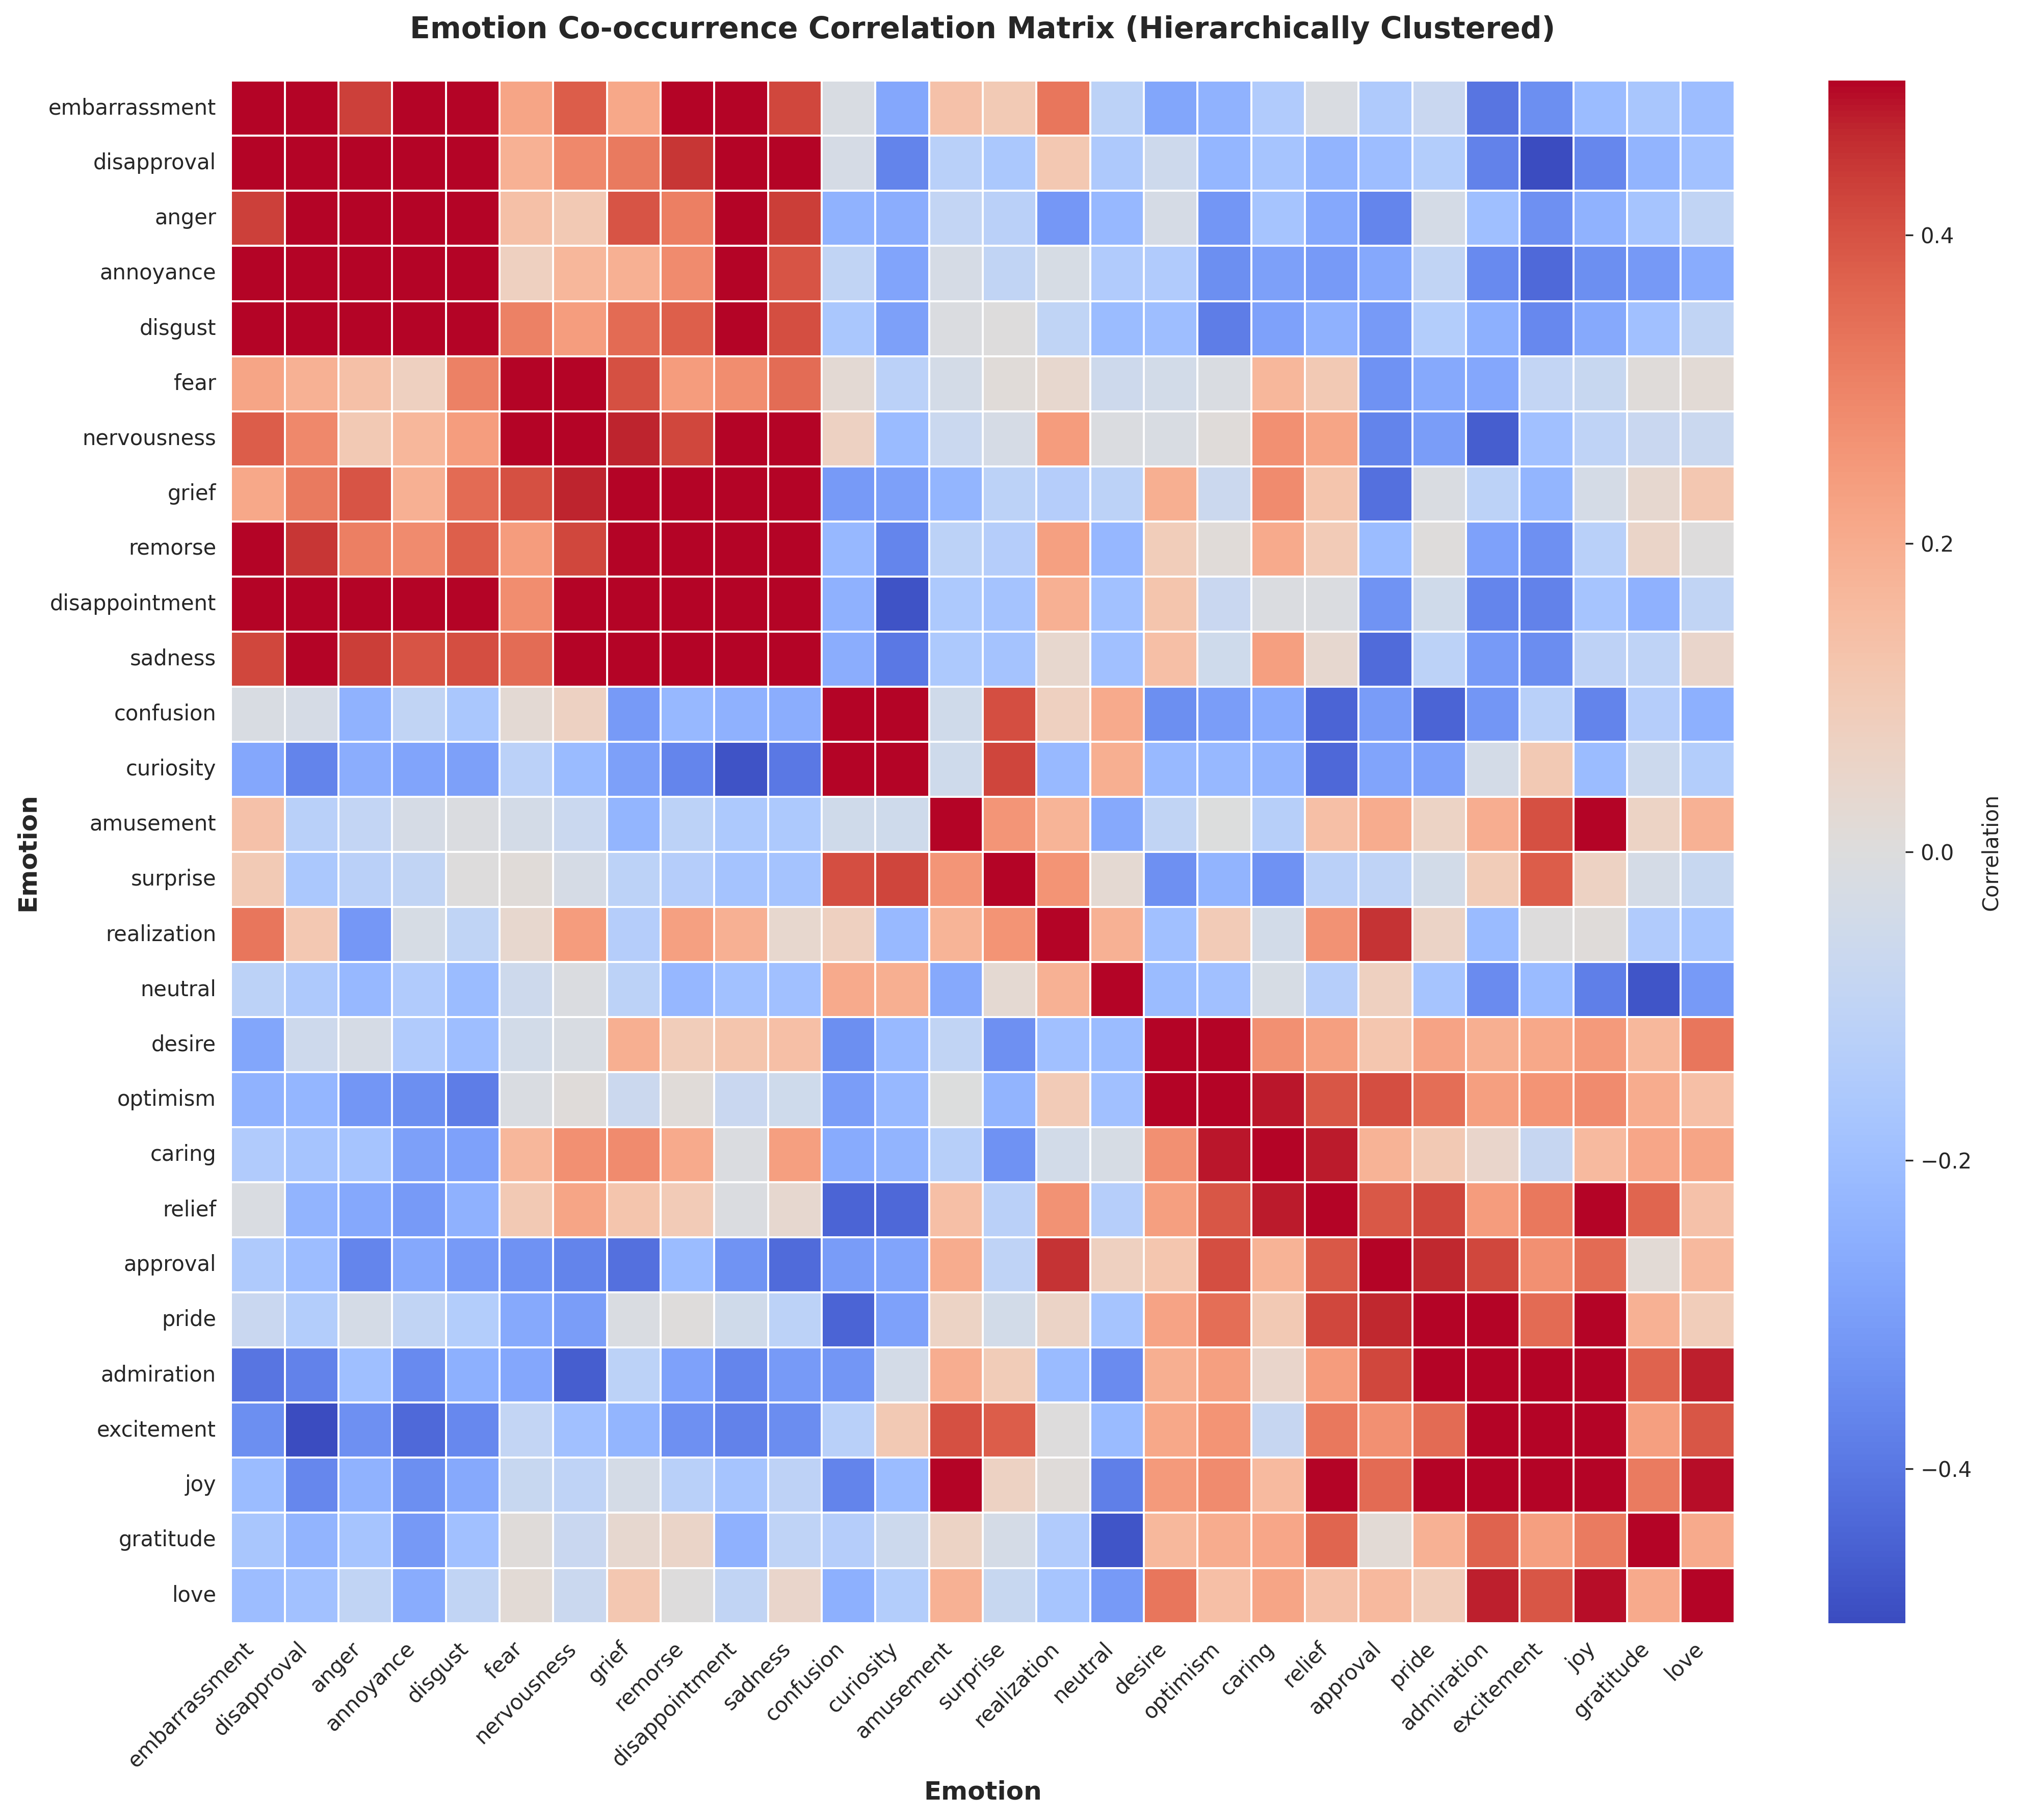

In [10]:
emotion_corr = df_topics[ALL_EMOTIONS].corr()

row_linkage = linkage(pdist(emotion_corr, metric='euclidean'), method='ward')
col_linkage = linkage(pdist(emotion_corr.T, metric='euclidean'), method='ward')

dendro = dendrogram(row_linkage, no_plot=True)
emotion_order = [ALL_EMOTIONS[i] for i in dendro['leaves']]
emotion_corr_sorted = emotion_corr.loc[emotion_order, emotion_order]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(emotion_corr_sorted, annot=False, cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, cbar_kws={'label': 'Correlation'},
            linewidths=0.5, ax=ax)
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('Emotion Co-occurrence Correlation Matrix (Hierarchically Clustered)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'emotion_correlation_matrix.png'), bbox_inches='tight')
plt.show()

## 6. Hierarchical Clustering Dendrogram

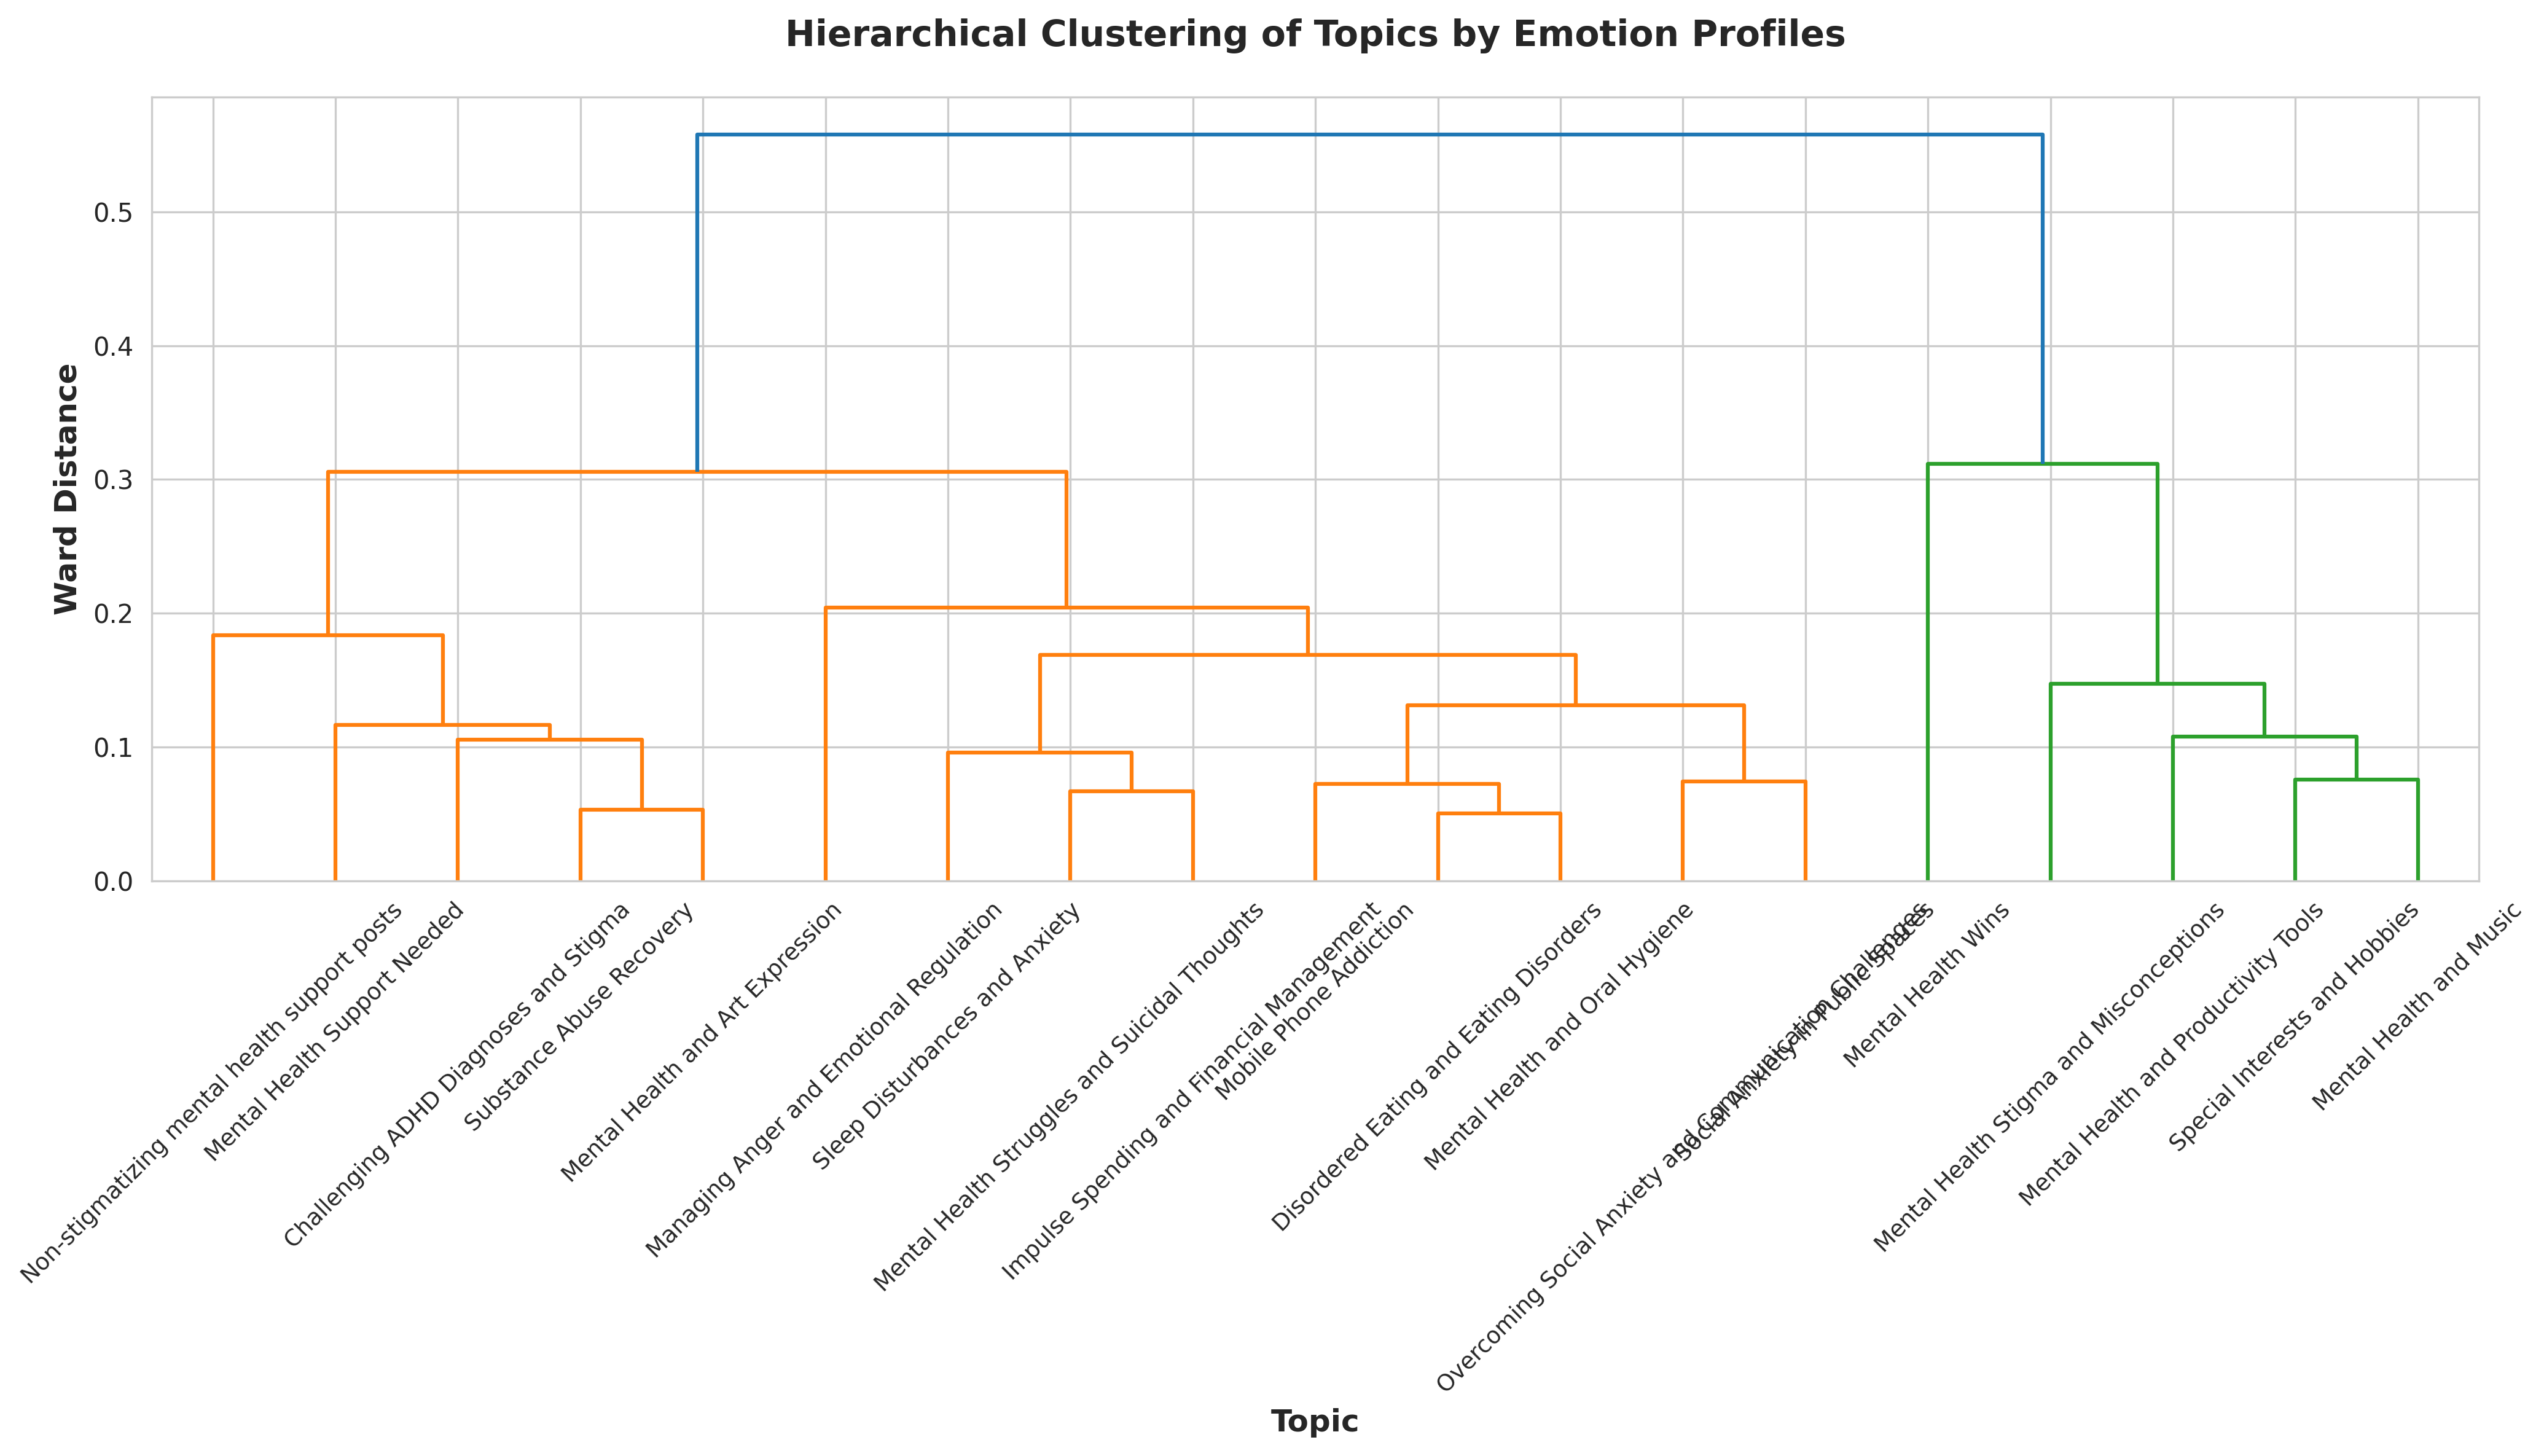

In [11]:
topic_linkage = linkage(emotion_by_topic, method='ward')

fig, ax = plt.subplots(figsize=(14, 8))
dendro = dendrogram(topic_linkage, labels=emotion_by_topic.index.tolist(),
                     leaf_rotation=45, leaf_font_size=9, ax=ax)
ax.set_xlabel('Topic', fontsize=12, fontweight='bold')
ax.set_ylabel('Ward Distance', fontsize=12, fontweight='bold')
ax.set_title('Hierarchical Clustering of Topics by Emotion Profiles',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'topic_emotion_dendrogram.png'), bbox_inches='tight')
plt.show()

## 7. Dominant Emotion Distribution

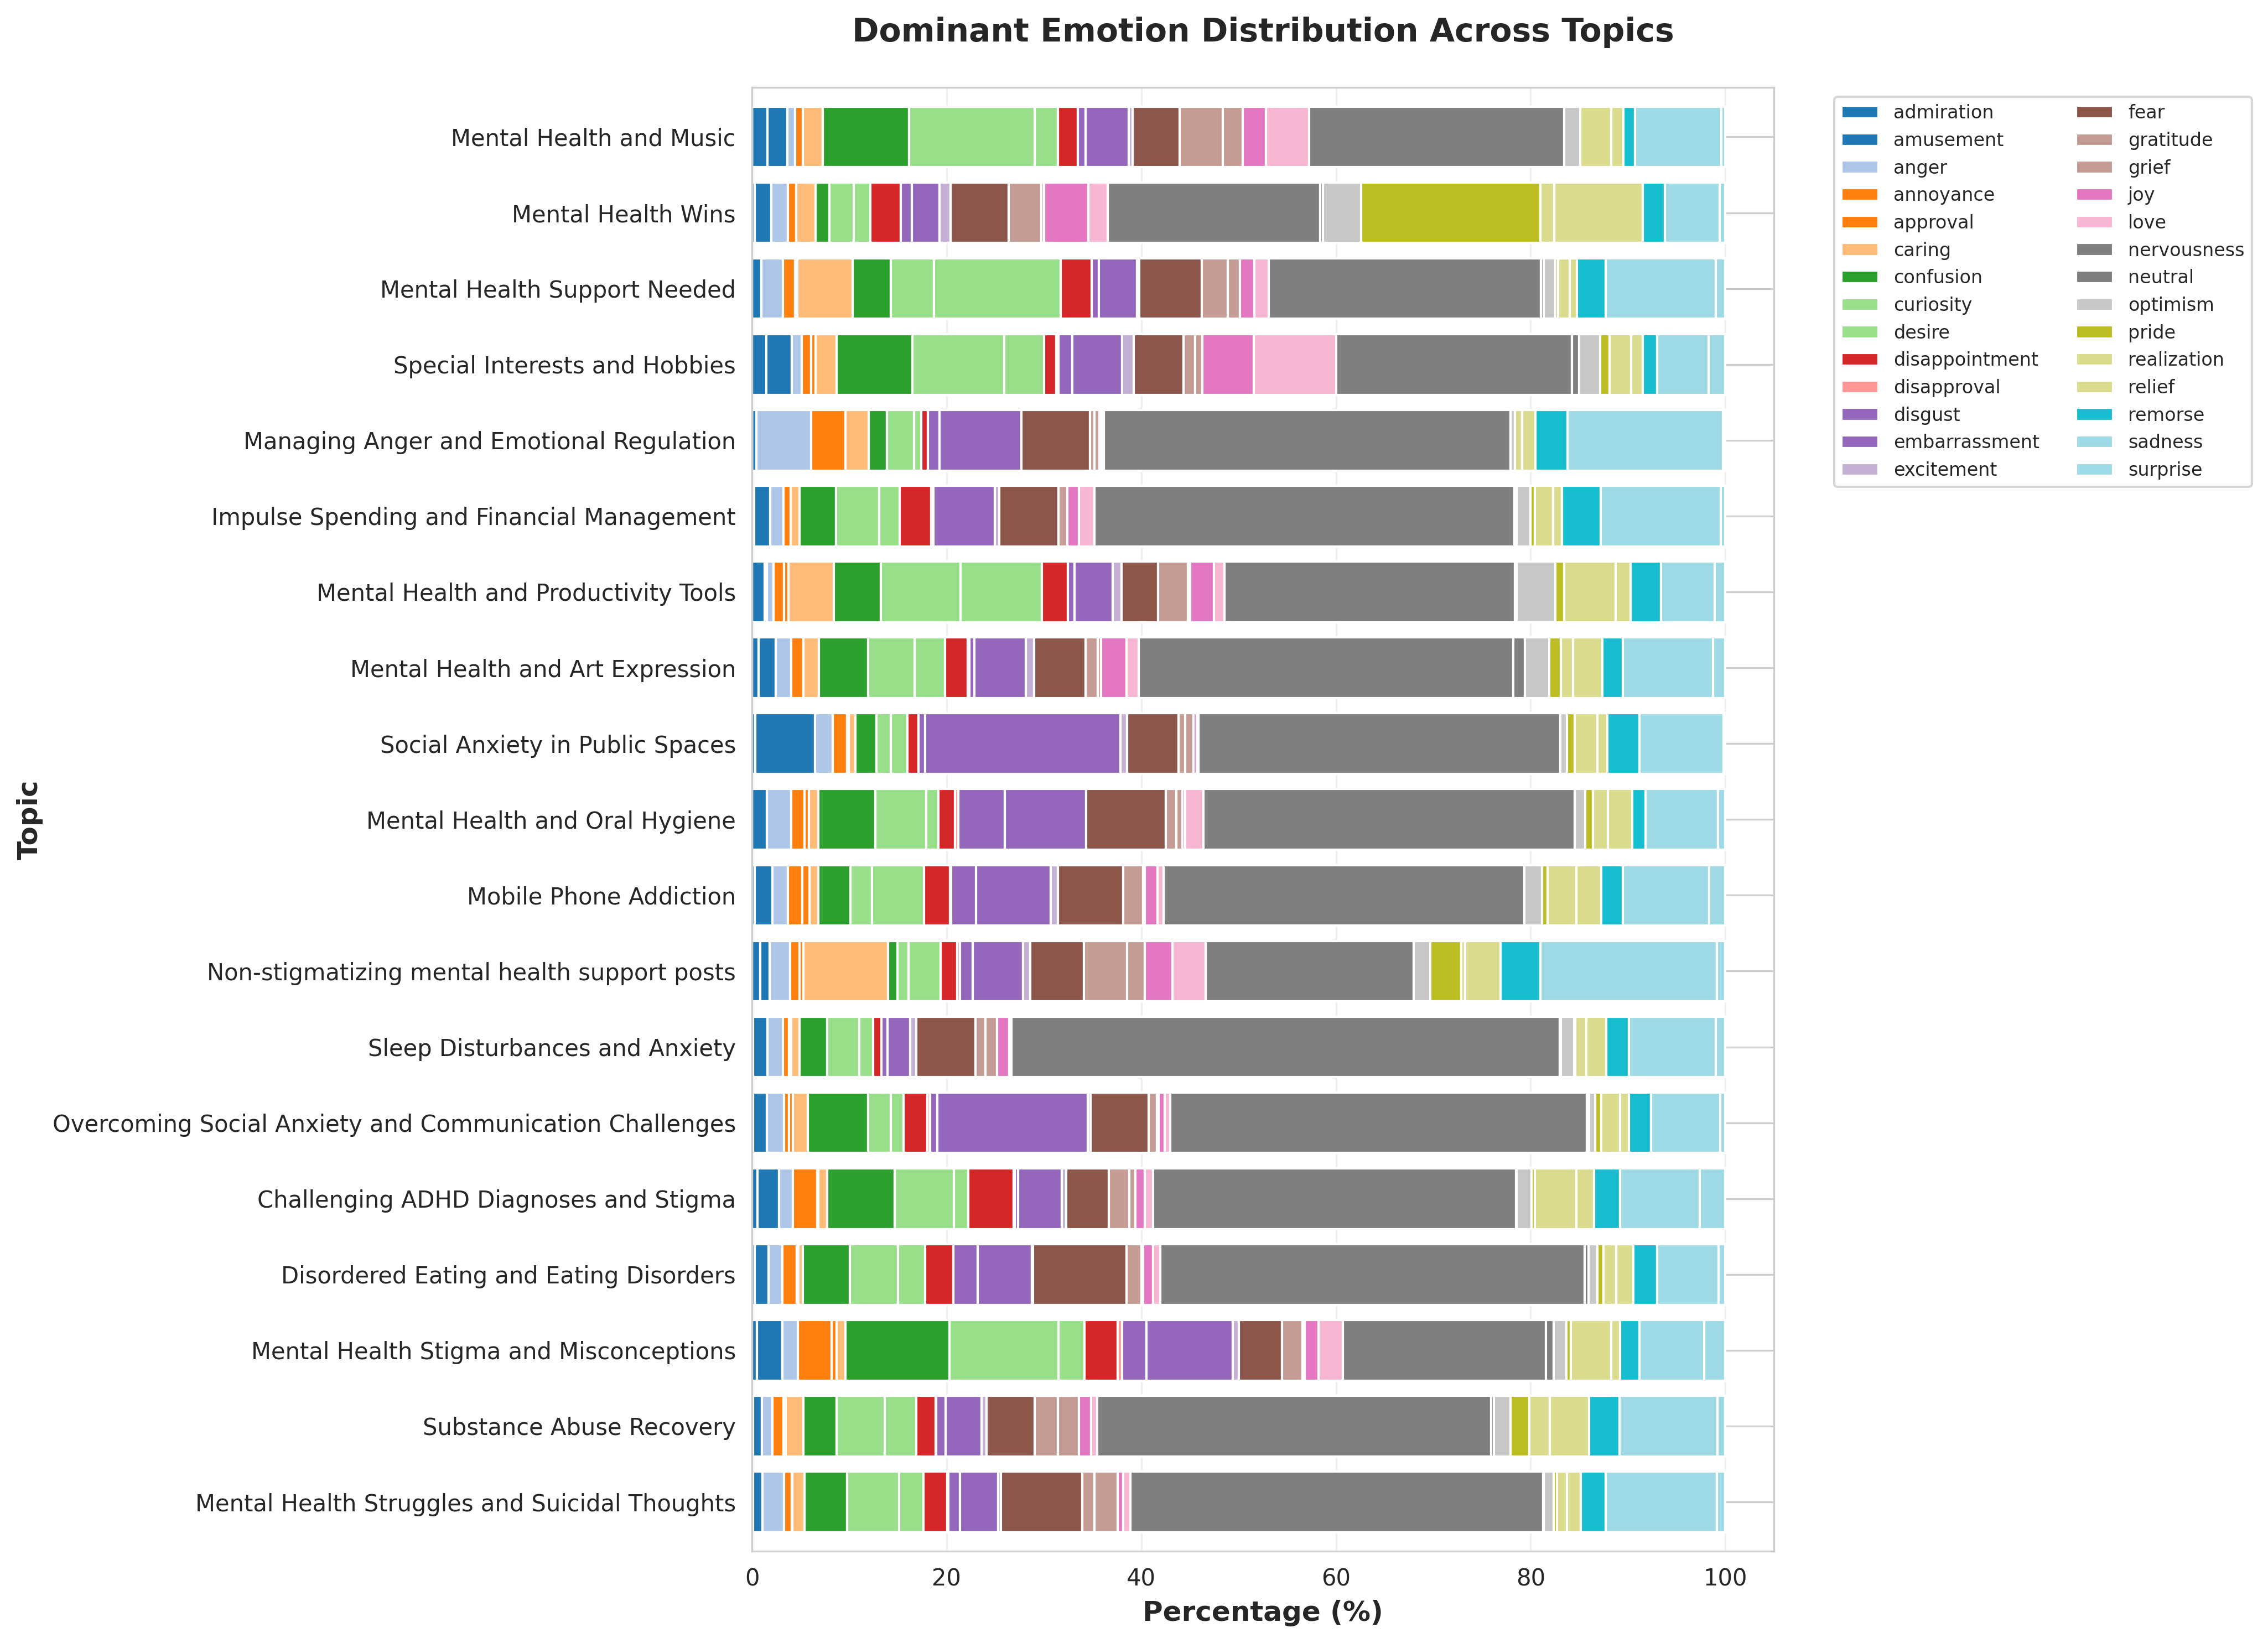

In [12]:
df_topics['dominant_emotion'] = df_topics[ALL_EMOTIONS].idxmax(axis=1)

dominant_dist = pd.crosstab(df_topics['topic'], df_topics['dominant_emotion'], normalize='index') * 100
dominant_dist.index = dominant_dist.index.map(lambda x: topic_names.get(x, f'Topic {x}'))

topic_counts = df_topics['topic'].map(lambda x: topic_names.get(x, f'Topic {x}')).value_counts()
dominant_dist = dominant_dist.loc[topic_counts.index]

fig, ax = plt.subplots(figsize=(14, 10))
dominant_dist.plot(kind='barh', stacked=True, ax=ax, width=0.8,
                    colormap='tab20', legend=False)
ax.set_xlabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Topic', fontsize=12, fontweight='bold')
ax.set_title('Dominant Emotion Distribution Across Topics', fontsize=14, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dominant_emotion_distribution.png'), bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [13]:
summary_stats = []

for topic_id in emotion_by_topic.index:
    topic_data = emotion_by_topic.loc[topic_id]

    original_id = reverse_topic_names.get(topic_id, None)
    post_count = len(df_topics[df_topics['topic'] == original_id]) if original_id is not None else 0

    top_3 = topic_data.nlargest(3)

    summary_stats.append({
        'Topic': topic_id,
        'Post_Count': post_count,
        'Mean_Emotion_Prob': topic_data.mean(),
        'Std_Emotion_Prob': topic_data.std(),
        'Top_Emotion_1': top_3.index[0],
        'Top_Emotion_1_Prob': top_3.values[0],
        'Top_Emotion_2': top_3.index[1],
        'Top_Emotion_2_Prob': top_3.values[1],
        'Top_Emotion_3': top_3.index[2],
        'Top_Emotion_3_Prob': top_3.values[2]
    })

summary_df = pd.DataFrame(summary_stats)
summary_path = os.path.join(OUTPUT_DIR, '../summary_statistics.csv')
summary_df.to_csv(summary_path, index=False)